# Classification

Train multiple supervised models to predict language labels from extracted features.
We use an 80/20 stratified split and standardize the features.

In [11]:
from pathlib import Path
import hashlib

import numpy as np
import pandas as pd

from src.config import PROJECT_ROOT, resolve_dataset_dir
from src.data import build_feature_dataframe
from src.modeling import (
    build_classification_models,
    plot_confusion,
    save_metrics,
    speaker_group_from_path,
    split_data,
    split_data_group_stratified,
    summarize_metrics,
    train_and_evaluate,
)


In [12]:
features_path = PROJECT_ROOT / "data" / "processed" / "features.csv"

if features_path.exists():
    df = pd.read_csv(features_path)
else:
    dataset_dir = resolve_dataset_dir()
    df, _ = build_feature_dataframe(dataset_dir, cache_path=features_path)

print(f"Loaded features shape: {df.shape}")
print("\nSamples per class:")
print(df["language"].value_counts().sort_index())

print("\nExample paths (first 8 rows):")
for sample_path in df["path"].head(8):
    print(sample_path)

df.shape, df["language"].value_counts().sort_index()


Loaded features shape: (720, 128)

Samples per class:
language
German     180
Italian    180
Korean     180
Spanish    180
Name: count, dtype: int64

Example paths (first 8 rows):
/home/parsa/Downloads/Personal Projects/ML/Phase-2/data/raw/ML Dataset/German/female90/810101512_female_German_voice08.mp3.mp3
/home/parsa/Downloads/Personal Projects/ML/Phase-2/data/raw/ML Dataset/German/female90/810104049_female_german_voice14.mp3
/home/parsa/Downloads/Personal Projects/ML/Phase-2/data/raw/ML Dataset/German/female90/810104145_female_german_voice04.mp3
/home/parsa/Downloads/Personal Projects/ML/Phase-2/data/raw/ML Dataset/German/female90/810104145_female_german_voice18.mp3
/home/parsa/Downloads/Personal Projects/ML/Phase-2/data/raw/ML Dataset/German/female90/810103084_female_german_voice13.mp3
/home/parsa/Downloads/Personal Projects/ML/Phase-2/data/raw/ML Dataset/German/female90/810101380_female_german_voice10.mp3
/home/parsa/Downloads/Personal Projects/ML/Phase-2/data/raw/ML Dataset/German/

((720, 128),
 language
 German     180
 Italian    180
 Korean     180
 Spanish    180
 Name: count, dtype: int64)

## Speaker grouping (leakage check)

Folder names are mostly gender buckets (for example `male90`/`female90`),
not true speaker identities. For leakage-aware evaluation, speaker groups are
derived from filename IDs (for example `810101607_...`).


In [13]:
df_for_split = df.copy()
df_for_split["speaker_group"] = df_for_split["path"].apply(speaker_group_from_path)

print("Groups per class:")
print(df_for_split.groupby("language")["speaker_group"].nunique().sort_index())

speaker_groups = df_for_split["speaker_group"]
speaker_groups.value_counts().head(20)


Groups per class:
language
German     28
Italian    18
Korean     14
Spanish    18
Name: speaker_group, dtype: int64


speaker_group
Korean/810101459     20
Korean/810103153     20
Korean/810100094     20
Korean/810104272     18
Italian/810103252    15
Korean/810101394     15
Italian/810102393    14
Korean/220701055     14
Italian/810102443    13
Italian/810102474    13
Italian/810101441    12
German/810101453     11
Italian/810103147    11
German/810101607     10
German/810100162     10
Italian/810104250    10
Italian/810104256    10
Italian/810102480    10
Italian/810101502    10
Korean/810104285     10
Name: count, dtype: int64

## Train/test split

Default: stratified 80/20 split (`use_group_split=False`) to match the project
requirement. Optional: set `use_group_split=True` for speaker-disjoint
evaluation using extracted speaker IDs.


In [14]:
use_group_split = True
test_size = 0.2
random_state = 42

if use_group_split:
    X_train, X_test, y_train, y_test = split_data_group_stratified(
        df_for_split,
        label_col="language",
        path_col="path",
        group_col="speaker_group",
        test_size=test_size,
        random_state=random_state,
    )
else:
    X_train, X_test, y_train, y_test = split_data(
        df,
        label_col="language",
        test_size=test_size,
        random_state=random_state,
    )

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")


Train size: 560 | Test size: 160


In [15]:
if speaker_groups is not None:
    train_groups = set(speaker_groups.loc[X_train.index])
    test_groups = set(speaker_groups.loc[X_test.index])
    overlap = train_groups.intersection(test_groups)
    print(f"Group overlap count: {len(overlap)}")
    if overlap:
        print("Overlapping groups sample:", sorted(overlap)[:10])
    assert len(overlap) == 0, "Leakage detected: train/test groups overlap."
else:
    train_groups = set()
    test_groups = set()

train_paths = set(df_for_split.loc[X_train.index, "path"])
test_paths = set(df_for_split.loc[X_test.index, "path"])
path_overlap = train_paths.intersection(test_paths)
print(f"Path overlap count: {len(path_overlap)}")
assert len(path_overlap) == 0, "Leakage detected: duplicated paths across train/test."

run_audio_hash_check = True

def file_md5(path, chunk_size=1024 * 1024):
    digest = hashlib.md5()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

hash_overlap = set()
if run_audio_hash_check:
    train_hashes = {file_md5(path) for path in train_paths if Path(path).exists()}
    test_hashes = {file_md5(path) for path in test_paths if Path(path).exists()}
    hash_overlap = train_hashes.intersection(test_hashes)
    print(f"Audio hash overlap count: {len(hash_overlap)}")
    assert len(hash_overlap) == 0, "Leakage detected: identical audio bytes across train/test."
else:
    print("Audio hash check skipped (run_audio_hash_check=False).")

possible_leakage_cols = [
    col
    for col in X_train.columns
    if any(token in col.lower() for token in ["language", "path", "speaker", "group", "label", "target"])
    or col.lower() == "id"
    or col.lower().endswith("_id")
]
print("Potential leakage columns in X_train:", possible_leakage_cols)
assert not possible_leakage_cols, "Potential leakage columns are present in X_train."

non_numeric_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
print("Non-numeric columns in X_train:", non_numeric_cols)
assert not non_numeric_cols, "Non-numeric columns remain in X_train."


Group overlap count: 0
Path overlap count: 0
Audio hash overlap count: 0
Potential leakage columns in X_train: []
Non-numeric columns in X_train: []


## Model training

In [16]:
use_pca = False
pca_components = 0.95

models = build_classification_models(use_pca=use_pca, pca_components=pca_components)
metrics, predictions = train_and_evaluate(models, X_train, X_test, y_train, y_test)

## Summary metrics

In [17]:
summary = {name: summarize_metrics(y_test, y_pred) for name, y_pred in predictions.items()}
summary_df = pd.DataFrame(summary).T.sort_values("f1_weighted", ascending=False)

metric_cols = ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]
all_ones = bool((summary_df[metric_cols] == 1.0).all().all())
print(f"All core metrics are 1.0 across models: {all_ones}")

summary_df


All core metrics are 1.0 across models: True


,accuracy,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro
SVM_RBF,1.0,1.0,1.0,1.0,1.0,1.0,1.0
RandomForest,1.0,1.0,1.0,1.0,1.0,1.0,1.0
LogisticRegression,1.0,1.0,1.0,1.0,1.0,1.0,1.0
KNN,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [18]:
best_model = summary_df.index[0]
report_df = pd.DataFrame(metrics[best_model]).T
report_df

,precision,recall,f1-score,support
German,1.0,1.0,1.0,38.0
Italian,1.0,1.0,1.0,35.0
Korean,1.0,1.0,1.0,47.0
Spanish,1.0,1.0,1.0,40.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,160.0
weighted avg,1.0,1.0,1.0,160.0


## Confusion matrices

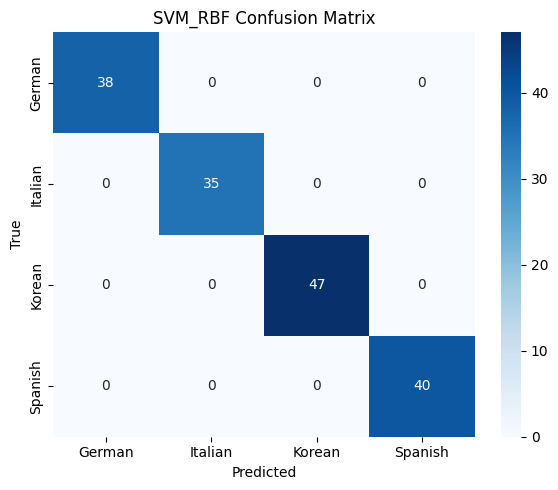

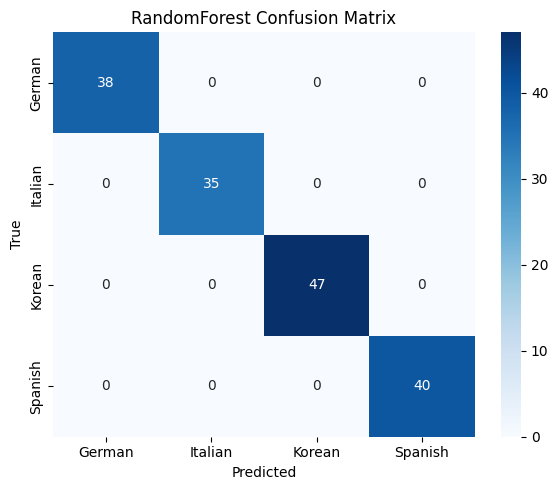

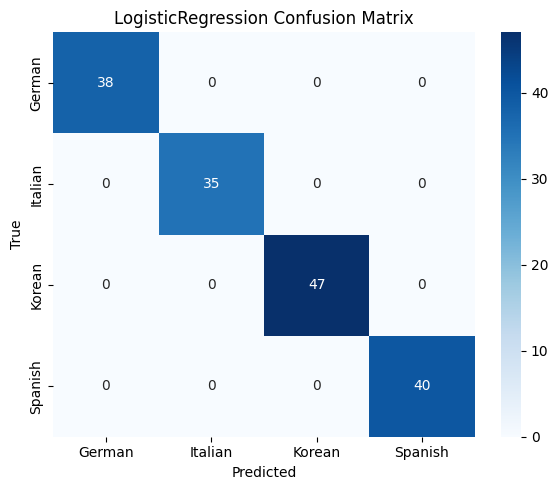

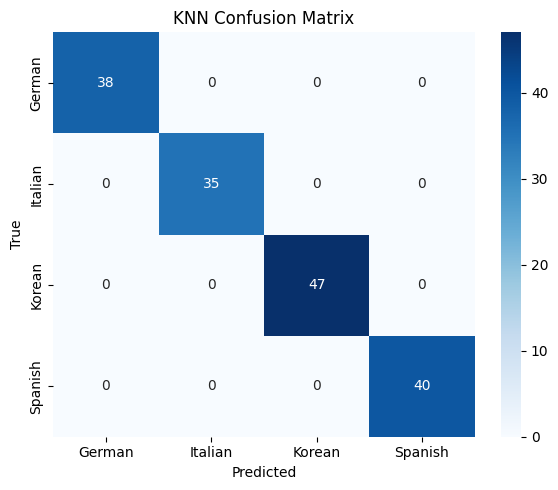

In [19]:
labels = sorted(y_test.unique())
for name, y_pred in predictions.items():
    plot_confusion(
        y_test,
        y_pred,
        labels=labels,
        title=f"{name} Confusion Matrix",
        save_path=PROJECT_ROOT / "reports" / "figures" / f"confusion_{name}.png",
    )

In [20]:
summary_out = PROJECT_ROOT / "data" / "processed" / "classification_summary.csv"
metrics_out = PROJECT_ROOT / "data" / "processed" / "classification_metrics.json"

summary_df.to_csv(summary_out)
save_metrics(metrics, metrics_out)

print(f"Saved summary: {summary_out}")
print(f"Saved metrics: {metrics_out}")


Saved summary: /home/parsa/Downloads/Personal Projects/ML/Phase-2/data/processed/classification_summary.csv
Saved metrics: /home/parsa/Downloads/Personal Projects/ML/Phase-2/data/processed/classification_metrics.json
